Generating Random Linear Data

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
rng = np.random.default_rng(seed=12)
m = 200
X = 2 * rng.random((m, 1)) 
y = 4 + 3 * X + rng.standard_normal((m, 1)) 

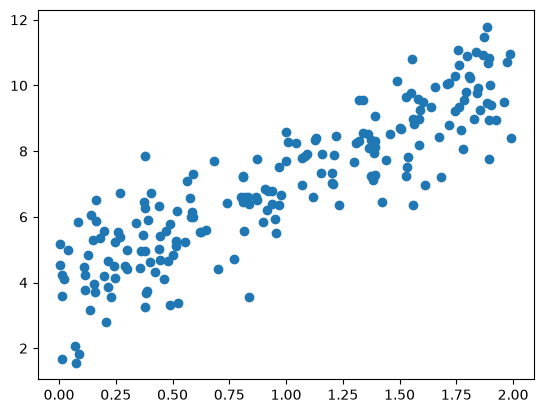

In [4]:
plt.scatter(x=X, y=y)

In [5]:
from sklearn.preprocessing import add_dummy_feature
X_b = add_dummy_feature(X) # add x0 = 1 to each instance
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

In [6]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new) # add x0 = 1 to each instance
y_predict = X_new_b @ theta_best

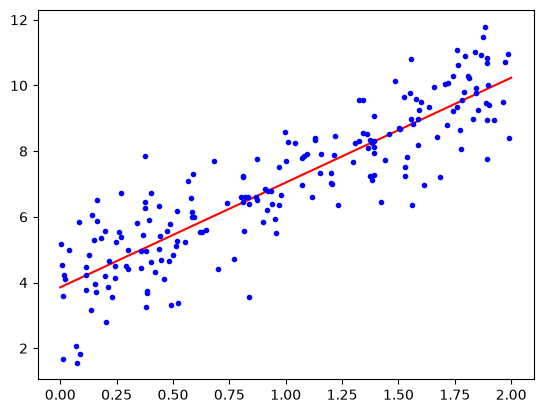

In [7]:
import matplotlib.pyplot as plt
plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.")

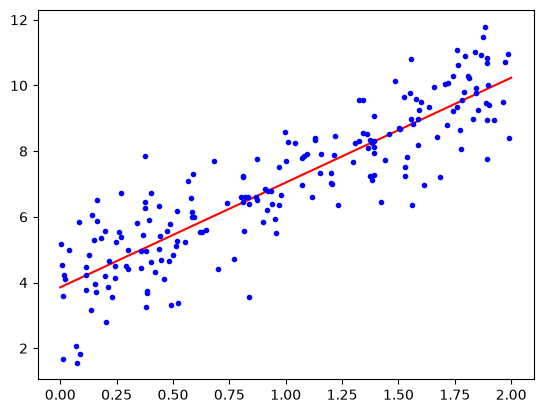

In [8]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X,y)
y_predict_lin_reg = lin_reg.predict([[0], [2]])

plt.plot(X_new, y_predict_lin_reg, "r-", label="Predictions")
plt.plot(X, y, "b.")

Batch Gradient Discent

In [9]:
eta = 0.1 # learning rate
n_epochs = 1000
m = len(X_b) # number of instances
rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1))

for epoch in range(n_epochs):
    gradients = 2 / m * X_b.T @ (X_b @ theta - y)
    theta = theta - eta * gradients

theta

array([[3.85386741],
       [3.19079672]])

Stochastic Gradient Descent

In [10]:
n_epochs = 50
t0, t1 = 5, 50 # learning schedule hyperparameters
def learning_schedule(t):
    return t0 / (t + t1)
rng = np.random.default_rng(seed=42)
theta_SD = rng.standard_normal((2, 1)) # randomly initialized model parameters
for epoch in range(n_epochs):
    for iteration in range(m):
        random_index = rng.integers(m)
        xi = X_b[random_index : random_index + 1]
        yi = y[random_index : random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta_SD - yi) # for SGD, do not divide by m
        eta = learning_schedule(epoch * m + iteration)
        theta_SD = theta_SD - eta * gradients

theta_SD

array([[3.85055134],
       [3.16250855]])

In [11]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.01,
n_iter_no_change=100, random_state=42)

sgd_reg.fit(X, y.ravel()) # y.ravel() because fit() expects 1D targets

sgd_reg.intercept_, sgd_reg.coef_

(array([3.85408297]), array([3.19120507]))

Ridge Regression

In [12]:
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha=0.1, solver="cholesky")
ridge_reg.fit(X, y)
y_predict_ridge_reg = ridge_reg.predict([[0],[2]])

In [13]:
sgd_reg = SGDRegressor(penalty="l2", alpha=0.1 / m, tol=None,
max_iter=1000, eta0=0.01, random_state=42)

sgd_reg.fit(X, y.ravel()) # y.ravel() because fit() expects 1D targets
y_predict_ridge_reg = ridge_reg.predict([[0],[2]])

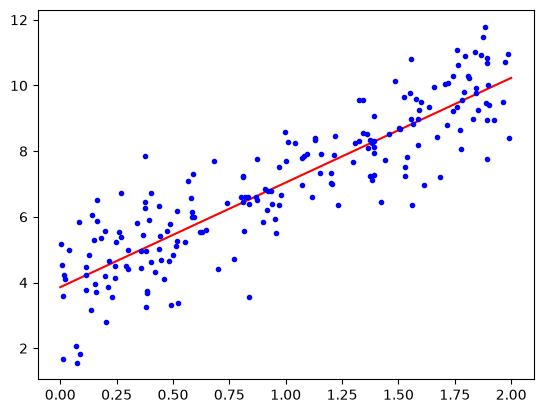

In [14]:
plt.plot(X_new, y_predict_ridge_reg, "r-", label="Predictions")
plt.plot(X, y, "b.")

Lasso Regression

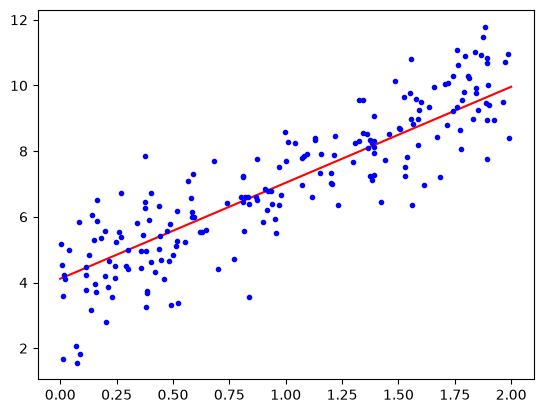

In [15]:
from sklearn.linear_model import Lasso
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)
y_predict_lasso_reg = lasso_reg.predict([[0], [2]])

plt.plot(X_new, y_predict_lasso_reg, "r-", label="Predictions")
plt.plot(X, y, "b.")

Elastic Net Regression

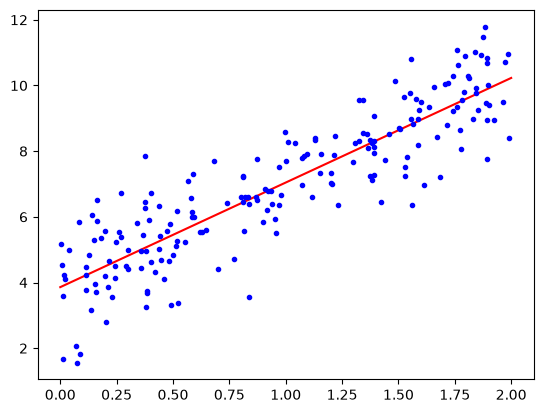

In [16]:
from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet(alpha=0.001, l1_ratio=0.5)
elastic_net.fit(X, y)
y_predict_elastic_new = elastic_net.predict([[0], [2]])

plt.plot(X_new, y_predict_elastic_new, "r-", label="Predictions")
plt.plot(X, y, "b.")

Learning Curves

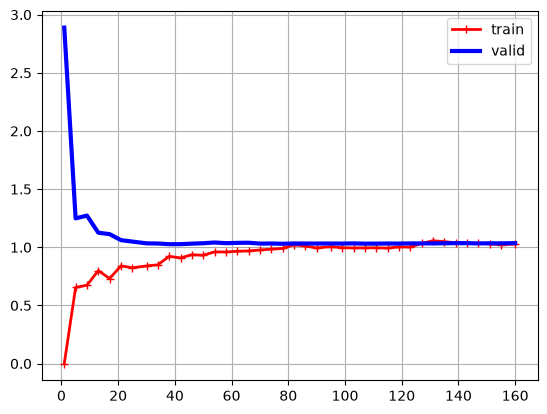

In [17]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(
LinearRegression(), X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error")
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.grid()
plt.legend()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/uti

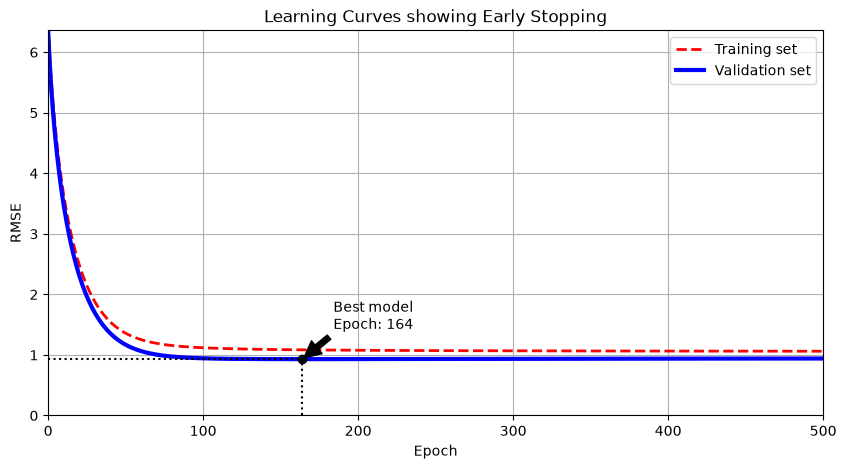

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from copy import deepcopy
from sklearn.metrics import root_mean_squared_error

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessing = make_pipeline(PolynomialFeatures(degree=90, include_bias=False),
StandardScaler())
X_train_prep = preprocessing.fit_transform(X_train)
X_valid_prep = preprocessing.transform(X_valid)
sgd_reg = SGDRegressor(penalty=None, eta0=0.002, random_state=42)
n_epochs = 500
best_valid_rmse = float('inf')

train_errors = []
valid_errors = []

for epoch in range(n_epochs):
    sgd_reg.partial_fit(X_train_prep, y_train)
    
    # Calculate and store Training Error
    y_train_predict = sgd_reg.predict(X_train_prep)
    train_rmse = root_mean_squared_error(y_train, y_train_predict)
    train_errors.append(train_rmse)
    
    # Calculate and store Validation Error
    y_valid_predict = sgd_reg.predict(X_valid_prep)
    val_rmse = root_mean_squared_error(y_valid, y_valid_predict)
    valid_errors.append(val_rmse)
    
    # Checkpoint the best model
    if val_rmse < best_valid_rmse:
        best_valid_rmse = val_rmse
        best_model = deepcopy(sgd_reg)
        best_epoch = epoch

# Create the plot
plt.figure(figsize=(10, 5))

# Plot both error lines
plt.plot(train_errors, "r--", linewidth=2, label="Training set")
plt.plot(valid_errors, "b-", linewidth=3, label="Validation set")

# Draw dotted lines intersecting at the best epoch
plt.plot([best_epoch, best_epoch], [0, best_valid_rmse], "k:") # Vertical line
plt.plot([0, best_epoch], [best_valid_rmse, best_valid_rmse], "k:") # Horizontal line
plt.plot(best_epoch, best_valid_rmse, "ko") # Black dot at the minimum

# Add an arrow pointing to the best model
plt.annotate(f'Best model\nEpoch: {best_epoch}', 
             xy=(best_epoch, best_valid_rmse), 
             xytext=(best_epoch + 20, best_valid_rmse + 0.5),
             arrowprops=dict(facecolor='black', shrink=0.05))

# Labels and formatting
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Learning Curves showing Early Stopping")
plt.legend(loc="upper right")

# We limit the y-axis because errors can be massive in the first few epochs
plt.axis([0, n_epochs, 0, max(valid_errors[:100])]) 
plt.grid(True)
plt.show()